In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import muon as mu

PROJECT_ROOT = r"C:\Users\mniu\Documents\neuroblastoma-multiome"

# Test on Be2c
adata_atac = ad.read_h5ad(os.path.join(PROJECT_ROOT, "data", "raw", "GSM8159270_Be2c_atac.h5ad"))
print(adata_atac)
print(f"Shape: {adata_atac.shape}")

AnnData object with n_obs × n_vars = 11695 × 216035
Shape: (11695, 216035)


In [3]:
# Fix barcode format
adata_atac.obs_names = adata_atac.obs_names.str.replace(".", "-", regex = False)

# Verify overlap with RNA
adata_rna = sc.read_h5ad(os.path.join(PROJECT_ROOT, "data", "processed", "Be2c_rna_processed.h5ad"))
rna_barcodes = set(adata_rna.obs_names)
atac_barcodes = set(adata_atac.obs_names)
print(f"RNA cells: {len(rna_barcodes)}")
print(f"ATAC cells: {len(atac_barcodes)}")
print(f"Overlap: {len(rna_barcodes & atac_barcodes)}")

RNA cells: 16818
ATAC cells: 11695
Overlap: 11695


In [4]:
# Number of peaks detected per cell
adata_atac.obs['n_peaks'] = np.diff(adata_atac.X.tocsr().indptr)

# Total accessibility counts per cell
adata_atac.obs['total_counts'] = np.asarray(adata_atac.X.sum(axis = 1)).flatten()

print(adata_atac.obs[['n_peaks', 'total_counts']].describe())

            n_peaks  total_counts
count  11695.000000  11695.000000
mean    9756.791877  12373.471484
std     6444.801335   9473.705600
min     1214.000000   1285.000000
25%     4398.000000   4821.500000
50%     8379.000000   9792.000000
75%    13977.000000  17572.500000
max    34999.000000  55577.000000


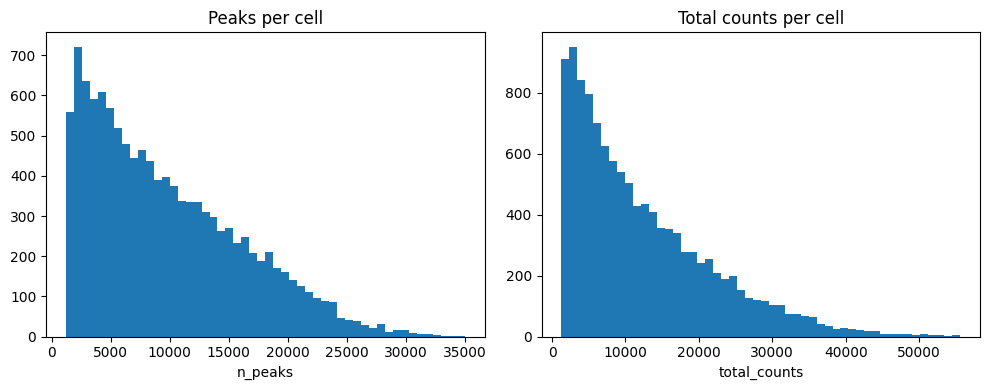

In [7]:
# Visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (10, 4))
axes[0].hist(adata_atac.obs['n_peaks'], bins = 50)
axes[0].set_title('Peaks per cell')
axes[0].set_xlabel('n_peaks')

axes[1].hist(adata_atac.obs['total_counts'], bins = 50)
axes[1].set_title('Total counts per cell')
axes[1].set_xlabel('total_counts')

plt.tight_layout()
plt.show()

In [13]:
# Filtering
print(f"Before filtering: {adata_atac.shape}")

# Filter cells with too few peaks (bottom ~10% roughly)
min_peaks = 2000
adata_atac = adata_atac[adata_atac.obs['n_peaks'] >= min_peaks].copy()
print(f"After min_peaks filter: {adata_atac.shape}")

# Filter peaks detected in too few cells
peak_cell_counts = np.diff(adata_atac.X.tocsc().indptr)
print(f"Peaks with <5 cells: {(peak_cell_counts < 5).sum()}")
adata_atac = adata_atac[:, peak_cell_counts >= 5].copy()
print(f"After peak filter: {adata_atac.shape}")

Before filtering: (11026, 216035)
After min_peaks filter: (11026, 216035)
Peaks with <5 cells: 0
After peak filter: (11026, 216035)


In [11]:
print(f"Min cells per peak: {peak_cell_counts.min()}")
print(f"Peaks with < 5 cells: {(peak_cell_counts < 5).sum()}")
print(f"Peaks with 0 cells: {(peak_cell_counts == 0).sum()}")

Min cells per peak: 16
Peaks with < 5 cells: 0
Peaks with 0 cells: 0


In [14]:
# TF-IDF Normalization
mu.atac.pp.tfidf(adata_atac, scale_factor = 1e4)
print("TF-IDF complete")
print(type(adata_atac.X))

TF-IDF complete
<class 'scipy.sparse._csr.csr_matrix'>


In [15]:
# LSI Dimensionality Reduction
mu.atac.tl.lsi(adata_atac)
print(adata_atac)

AnnData object with n_obs × n_vars = 11026 × 216035
    obs: 'n_peaks', 'total_counts'
    uns: 'lsi'
    obsm: 'X_lsi'
    varm: 'LSI'


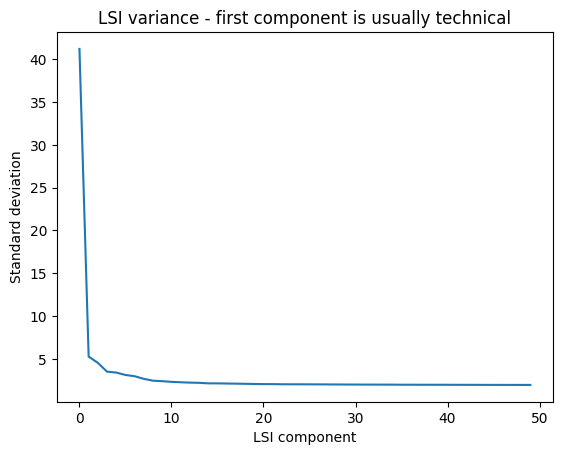

In [16]:
# Visualize
plt.plot(adata_atac.uns['lsi']['stdev'])
plt.xlabel('LSI component')
plt.ylabel('Standard deviation')
plt.title('LSI variance - first component is usually technical')
plt.show()

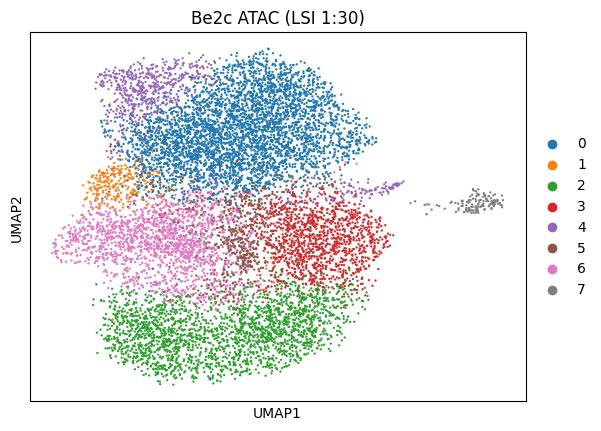

In [19]:
#Neighbors + UMAP on ATAC
# Skip first LSI component (technical)
adata_atac.obsm['X_lsi_filtered'] = adata_atac.obsm['X_lsi'][:, 1:30]
sc.pp.neighbors(adata_atac, use_rep = 'X_lsi_filtered', n_neighbors = 15)
sc.tl.umap(adata_atac)
sc.tl.leiden(adata_atac, resolution = 0.5, flavor = "igraph", n_iterations = 2, directed = False)
sc.pl.umap(adata_atac, color = 'leiden', title = 'Be2c ATAC (LSI 1:30)')

In [21]:
# Check cluster 7
qc_atac = adata_atac.obs.groupby('leiden', observed = True)[['n_peaks', 'total_counts']].mean()
print(qc_atac.sort_values('n_peaks'))

             n_peaks  total_counts
leiden                            
5        9009.810945  11324.966833
4        9292.862958  11549.491180
0        9546.938954  11674.400050
3        9906.047833  13029.016442
7       10175.738462  13327.523077
2       11120.348716  14569.719634
1       11447.770992  14616.354962
6       11695.158845  15088.884477


In [22]:
# Save
out_path = os.path.join(PROJECT_ROOT, "data", "processed", "Be2c_atac_processed.h5ad")
adata_atac.write_h5ad(out_path, compression = 'gzip')
print(f"Saved: {out_path}")

Saved: C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\Be2c_atac_processed.h5ad


## Week 3 Day 3 - ATAC Preprocessing (Be2c)

### Pipeline Differences from RMA
ATAC preprocessing uses a fundamentally different approach from RNA:
- Features are genomic peaks (~216000) rather than genes (~28000)
- TF-IDF normalization (term frequency-inverse document frequency) is used instead of normalize_total + log1p, since ATAC data is binary-like rather than continuous count data
- LSI (Latent Semantic Indexing) replaces PCA for dimansionality reduction
- The first LSI component is dominated by sequencing depth (technical artifact) and is excluded from downstream neighbor graph construction

### Results
- Be2c ATAC starting shape: 11695 cellx x 216035 peaks
- After filtering (min_peaks = 2000): 11026 cells (94.3% retained)
- Peak filtering applied no removal: all 216035 peaks detected in >= 16 cells, suggesting upstream QC was already applied by the data depositors
- TF-IDF normalization applied
- LSI computed (50 components), first component skipped due to depth artifact (std = 41 vs ~5 for component 2)
- 8 Leiden clusters identified (resolution = 0.5) on LSI components 1:30
- Cluster QC analysis showed all clusters have similarpeakdetection levels (range 9010-11695 peaks/cells), suggesting cluster structure reflects genuine biological variation rather than technical artifacts
- Cluster 7 (visually isolated in UMAP) has mid-range QC metrics, consistent with a real biological subpopulation rather than low-quality cells

### Comparison with RNA
- RNA clustering yielded 9 clusters. ATAC yielded 8m similar granularity
- Both modalities show one visually isolated cluster (RNA cluster 8 / ATAC cluster 7), though it remains to be determined whether these represent the same cells biologically (to be examined when modalities are paired in Day 4)